Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.99MB/s]


Training with Sigmoid activation...
Sigmoid: Final Test Accuracy: 97.88%, Training Time: 205.61s
Training with Tanh activation...
Tanh: Final Test Accuracy: 97.80%, Training Time: 208.34s
Training with ReLU activation...
ReLU: Final Test Accuracy: 97.74%, Training Time: 208.24s
Training with LeakyReLU activation...
LeakyReLU: Final Test Accuracy: 97.90%, Training Time: 203.68s


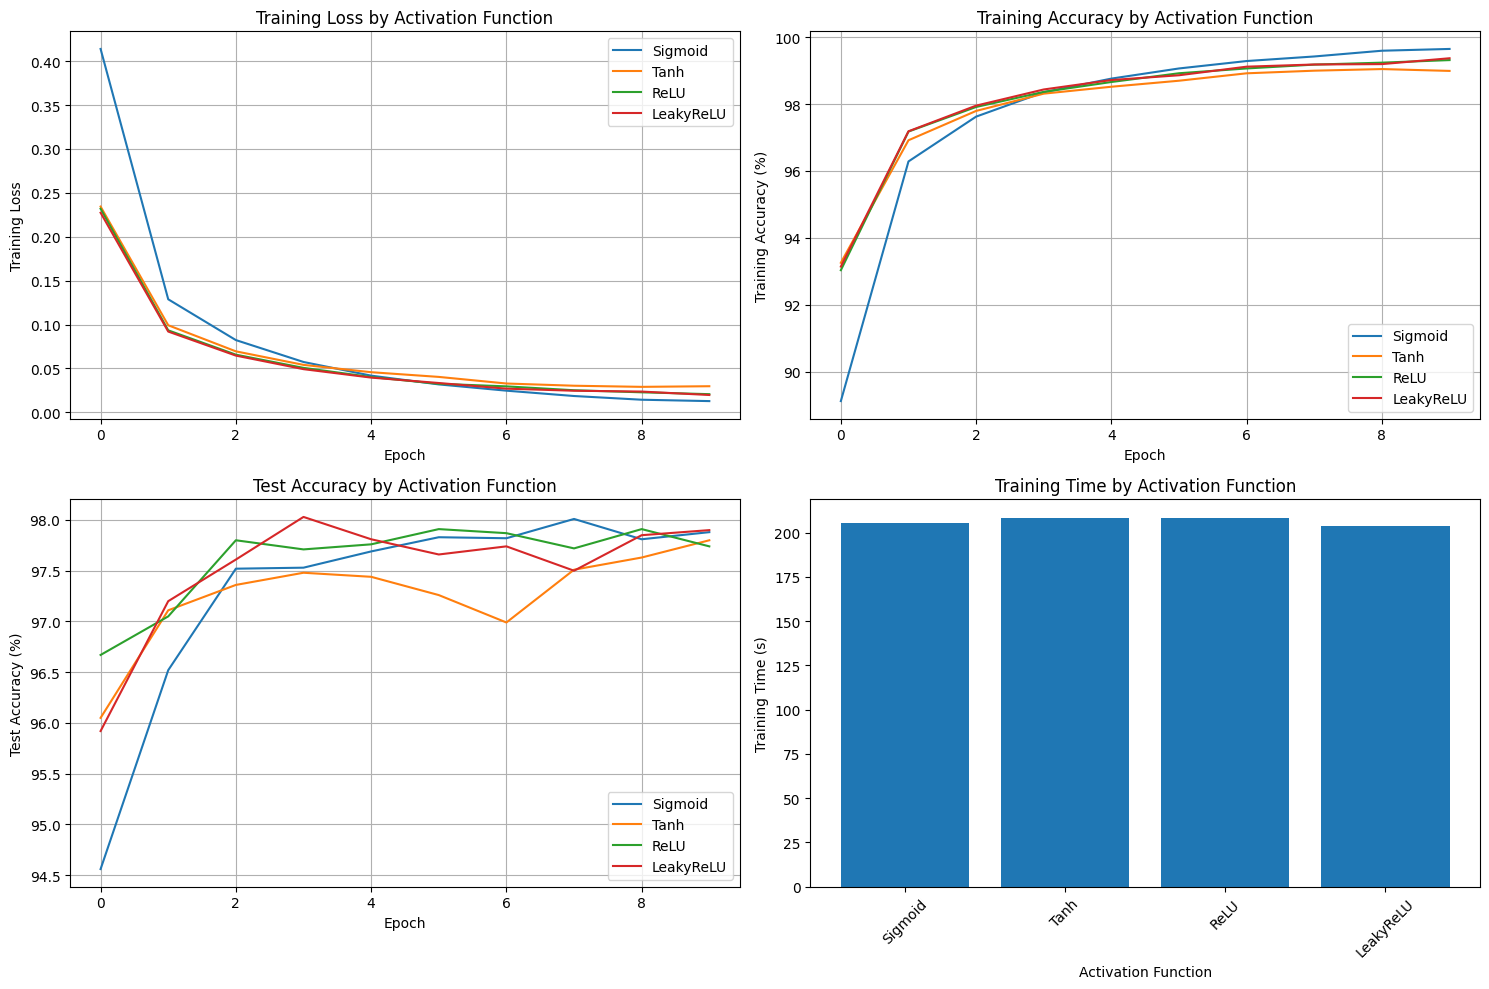


=== Activation Function Comparison ===
Activation   Final Train Acc Final Test Acc  Training Time (s)
------------------------------------------------------------
Sigmoid      99.65           97.88           205.61         
Tanh         98.99           97.80           208.34         
ReLU         99.31           97.74           208.24         
LeakyReLU    99.37           97.90           203.68         

=== Why Some Activations Perform Better ===

1. ReLU and Leaky ReLU:
   - Gradient preservation: ReLU maintains a gradient of 1 for positive inputs, preventing
     vanishing gradients in deep networks.
   - Computational efficiency: Simple max(0,x) operation is computationally cheap.
   - Sparsity: ReLU creates sparse representations which can be beneficial.
   - Leaky ReLU addresses the 'dying ReLU' problem by allowing small negative values.

2. Sigmoid and Tanh:
   - Vanishing gradient: For very positive or negative inputs, these functions saturate,
     causing gradients to approa

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

# Check for GPU and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Define activation functions to test
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.01)
}

# Track results
results = {
    name: {
        'train_losses': [],
        'train_accuracies': [],
        'test_accuracies': [],
        'training_time': 0
    }
    for name in activations.keys()
}

# Training parameters
epochs = 10
criterion = nn.CrossEntropyLoss()

# Train and evaluate each activation function
for name, activation in activations.items():
    print(f"Training with {name} activation...")

    # Build model with current activation
    model = nn.Sequential(
        nn.Linear(784, 256),
        activation,
        nn.Linear(256, 128),
        activation,
        nn.Linear(128, 10)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Track training metrics
    start_time = time.time()

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            images = images.view(images.size(0), -1)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track metrics
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calculate epoch metrics
        avg_loss = epoch_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train
        results[name]['train_losses'].append(avg_loss)
        results[name]['train_accuracies'].append(train_accuracy)

        # Test accuracy
        model.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                images = images.view(images.size(0), -1)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_accuracy = 100 * correct_test / total_test
        results[name]['test_accuracies'].append(test_accuracy)

    # Record training time
    results[name]['training_time'] = time.time() - start_time

    print(f"{name}: Final Test Accuracy: {test_accuracy:.2f}%, Training Time: {results[name]['training_time']:.2f}s")

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot training loss
for name in activations.keys():
    axes[0, 0].plot(results[name]['train_losses'], label=name)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss by Activation Function')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot training accuracy
for name in activations.keys():
    axes[0, 1].plot(results[name]['train_accuracies'], label=name)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Training Accuracy (%)')
axes[0, 1].set_title('Training Accuracy by Activation Function')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot test accuracy
for name in activations.keys():
    axes[1, 0].plot(results[name]['test_accuracies'], label=name)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Test Accuracy (%)')
axes[1, 0].set_title('Test Accuracy by Activation Function')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot training time
times = [results[name]['training_time'] for name in activations.keys()]
axes[1, 1].bar(activations.keys(), times)
axes[1, 1].set_xlabel('Activation Function')
axes[1, 1].set_ylabel('Training Time (s)')
axes[1, 1].set_title('Training Time by Activation Function')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary
print("\n=== Activation Function Comparison ===")
print(f"{'Activation':<12} {'Final Train Acc':<15} {'Final Test Acc':<15} {'Training Time (s)':<15}")
print("-" * 60)
for name in activations.keys():
    train_acc = results[name]['train_accuracies'][-1]
    test_acc = results[name]['test_accuracies'][-1]
    time_taken = results[name]['training_time']
    print(f"{name:<12} {train_acc:<15.2f} {test_acc:<15.2f} {time_taken:<15.2f}")

# Explanation of results
print("\n=== Why Some Activations Perform Better ===")
print("""
1. ReLU and Leaky ReLU:
   - Gradient preservation: ReLU maintains a gradient of 1 for positive inputs, preventing
     vanishing gradients in deep networks.
   - Computational efficiency: Simple max(0,x) operation is computationally cheap.
   - Sparsity: ReLU creates sparse representations which can be beneficial.
   - Leaky ReLU addresses the 'dying ReLU' problem by allowing small negative values.

2. Sigmoid and Tanh:
   - Vanishing gradient: For very positive or negative inputs, these functions saturate,
     causing gradients to approach zero and slowing down learning in deep networks.
   - Computational cost: More expensive operations (exponentials) compared to ReLU.
   - Output range: Sigmoid (0-1) and Tanh (-1 to 1) can cause issues in deep networks
     as signals are compressed at each layer.

3. Why ReLU variants excel in deep networks:
   - They mitigate the vanishing gradient problem, allowing for training of very deep networks.
   - They enable faster convergence due to constant gradient for positive inputs.
   - They induce sparsity which can lead to more efficient representations.

4. Practical considerations:
   - ReLU is a good default choice for most deep learning applications.
   - Leaky ReLU can be beneficial when facing the 'dying ReLU' problem.
   - Sigmoid and Tanh are still useful in specific contexts (e.g., output layers for
     binary classification or when bounded outputs are needed).
""")